In [156]:
import pandas as pd
cx_df = pd.read_csv(r'C:\Users\LENOVO\OneDrive\Desktop\Sql\Sql Joins and delete\customers.csv')
or_dx = pd.read_csv(r'C:\Users\LENOVO\OneDrive\Desktop\Sql\Sql Joins and delete\orders.csv')
print(cx_df.head())
print(or_dx.head())

   customer_id     customer_name             city
0            1    Anthony Garcia   Caitlinborough
1            2  Stephen Martinez        Davisland
2            3  Stephanie Miller    Mccormickport
3            4        Joanne Cox       Nathanberg
4            5    William Murphy  West Kellyville
   order_id  customer_id  order_date   amount
0         1          321  2025-06-04  1276.85
1         2          958  2024-05-05   680.65
2         3          955  2025-02-17  4467.50
3         4          402  2024-10-20  3698.02
4         5          510  2025-07-31  1359.00


In [157]:
# joined table
cx_or = cx_df.merge(or_dx, on='customer_id', how='left') # used left join so that we don't remove the nulls rows
cx_or.head()

,customer_id,customer_name,city,order_id,order_date,amount
0,1,Anthony Garcia,Caitlinborough,587.0,2024-05-21,517.92
1,1,Anthony Garcia,Caitlinborough,1300.0,2025-01-26,2791.25
2,1,Anthony Garcia,Caitlinborough,1332.0,2024-09-29,4050.03
3,1,Anthony Garcia,Caitlinborough,1836.0,2025-02-08,2387.11
4,1,Anthony Garcia,Caitlinborough,1889.0,2026-01-05,3510.92


In [158]:
# find customers who have not placed any order since last 3 months 
# Churned Customers (inactive)
# Customers with NO orders ever
df = cx_or.copy()
import pandas as pd

# get today's date as daily period (no time)
current_date = pd.Timestamp.today().to_period('D')

# define cutoff = 90 days before today (inactive threshold)
cutoff = current_date - 90

# convert order_date to datetime then to daily period (remove time)
df['order_date_period'] = pd.to_datetime(df['order_date'], errors='coerce').dt.to_period('D')

# get last order date per customer (max date - latest activity)
max_cx_date = df.groupby('customer_id', dropna=False)['order_date_period'].max()

# filter customers:
# 1. last order before cutoff - inactive (churned)
# 2. OR no orders at all - null - also inactive
filter_dates = max_cx_date[(max_cx_date < cutoff) | (max_cx_date.isnull())]

# count total inactive customers (including nulls)
filter_dates.shape[0]

804

In [159]:
import pandas as pd

# get today's date without time (same as SQL current_date)
current_date_1 = pd.Timestamp.today().normalize()

# define cutoff date 3 months before today
cutoff_1 = current_date_1 - pd.DateOffset(months=3)

# convert order_date to datetime and remove time
df['order_date_actual'] = pd.to_datetime(df['order_date'], errors='coerce').dt.normalize()

# get last order date for each customer
max_cx_date_1 = df.groupby('customer_id', dropna=False)['order_date_actual'].max()

# filter customers whose last order is before cutoff or have no orders
filter_dates_1 = max_cx_date_1[(max_cx_date_1 < cutoff_1) | (max_cx_date_1.isnull())]

# count total churned customers
filter_dates_1.shape[0]

804

In [160]:
# Find customers who placed an order in the last 7 days

# get today's date without time
current_date_1 = pd.Timestamp.today().normalize()

# define cutoff date 7 days before today
cutoff_1 = current_date_1 - pd.Timedelta(days=7)

# filter rows where order date is within last 7 days
filter_date = df[df['order_date_actual'] >= cutoff_1]

# count number of such records
filter_date.shape[0]

0

In [161]:
# Find customers who placed their first-ever order in the last 30 days

import pandas as pd

# get today's date without time (same as SQL current_date)
current_date_1 = pd.Timestamp.today().normalize()

# define cutoff date 30 days before today
cutoff_1 = current_date_1 - pd.Timedelta(days=30)

# get first order date for each customer (earliest order using min)
min_cx_date_1 = df.groupby('customer_id')['order_date_actual'].min()

# filter customers whose first order is within last 30 days (new customers)
filter_dates_1 = min_cx_date_1[min_cx_date_1 >= cutoff_1]

# count total new customers acquired in last 30 days
filter_dates_1.shape[0]

5

In [257]:
# Same above query in a different way
# Find customers who placed their first-ever order in the last 30 days
# get today's date without time (same as SQL current_date)
current_date_1 = pd.Timestamp.today().normalize()

# define cutoff date 30 days before today
cutoff_1 = current_date_1 - pd.Timedelta(days=30)

grouped = df.groupby('customer_id')['order_date_actual'].min().reset_index()
grouped = grouped[grouped['order_date_actual'] >=cutoff_1].style.hide(axis='index')
grouped

customer_id,order_date_actual
58,2026-03-26 00:00:00
81,2026-04-02 00:00:00
222,2026-03-31 00:00:00
260,2026-03-20 00:00:00
376,2026-03-29 00:00:00


In [163]:
# Find customers who placed their last order in the last 30 days

import pandas as pd

# get today's date without time (same as SQL current_date)
current_date_1 = pd.Timestamp.today().normalize()

# define cutoff date 30 days before today
cutoff_1 = current_date_1 - pd.Timedelta(days=30)

# get last order date for each customer (latest order using max)
max_cx_date_1 = df.groupby('customer_id')['order_date_actual'].max()

# filter customers whose last order is within last 30 days (active customers)
filter_dates_1 = max_cx_date_1[max_cx_date_1 >= cutoff_1]

# count total active customers in last 30 days
filter_dates_1.shape[0]

46

In [164]:
# find customers who purchased more than 1 time in the last month and show the date
import datetime
cutoff = pd.Period(datetime.date.today(), 'D') - 30
current_date = pd.Period(datetime.date.today(), 'D')
filter_data = df[(df['order_date_period'] >= cutoff) & (df['order_date_period'] < current_date)].copy()
filter_data['Count'] = filter_data.groupby('customer_id')['order_id'].transform('count')
filter_data.query('Count > 1')

,customer_id,customer_name,city,order_id,order_date,amount,order_date_period,order_date_actual,Count
170,80,Charles Garrett,Donfort,43.0,2026-03-27,1281.12,2026-03-27,2026-03-27,2
172,80,Charles Garrett,Donfort,1743.0,2026-03-28,1669.21,2026-03-28,2026-03-28,2


In [165]:
# find customers last month order and if not placed order show null
df['Month_Date'] = df['order_date_actual'].dt.to_period('M')
cutoff = pd.Period(datetime.date.today(), 'M') - 1
df[(df['Month_Date'] >= cutoff) & (df['Month_Date'] < pd.Period(datetime.date.today(), 'M')) | (df['order_id'].isnull())]

,customer_id,customer_name,city,order_id,order_date,amount,order_date_period,order_date_actual,Month_Date
5,2,Stephen Martinez,Davisland,NaN,NaN,NaN,NaT,NaT,NaT
16,6,Melody Kelly,Martinezport,314.0,2026-03-22,2214.05,2026-03-22,2026-03-22,2026-03
19,7,Kenneth Santiago,Riveraton,NaN,NaN,NaN,NaT,NaT,NaT
36,15,Nathan Taylor,Christinatown,NaN,NaN,NaN,NaT,NaT,NaT
41,16,Chad Bennett,Sandrastad,651.0,2026-03-24,1380.44,2026-03-24,2026-03-24,2026-03
...,...,...,...,...,...,...,...,...,...
2082,972,Laura Douglas,Lake Gabrielhaven,NaN,NaN,NaN,NaT,NaT,NaT
2102,981,Ashley Butler,North Tara,NaN,NaN,NaN,NaT,NaT,NaT
2103,982,Douglas Bell,South Laurenton,40.0,2026-03-05,828.90,2026-03-05,2026-03-05,2026-03
2122,990,Robert Adams,East Matthew,NaN,NaN,NaN,NaT,NaT,NaT


<Axes: xlabel='year'>

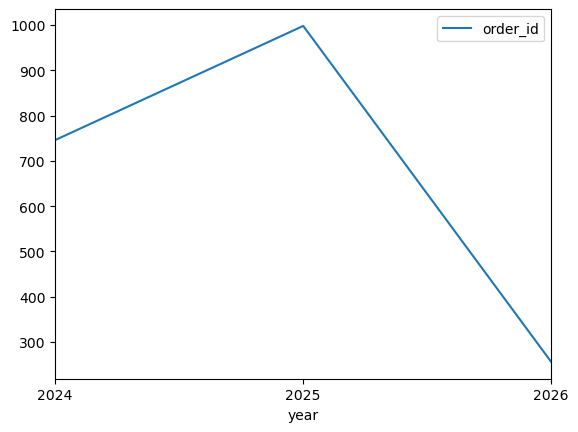

In [166]:
# Order counts by year
df['year'] = df['order_date_actual'].dt.to_period('Y')
result = df.groupby('year')['order_id'].count().reset_index().sort_values('year', ascending=False)
result.plot(x='year', y='order_id')

In [167]:
# Find customers who placed an order the next day after their first order

# Step 1: Select required columns only
df1 = df[['customer_id', 'order_date_actual']].copy()

# Step 2: Sort data by customer and order date
# This ensures correct chronological sequence of orders
df1 = df1.sort_values(['customer_id', 'order_date_actual'])

# Step 3: Get the first order date (cohort anchor) for each customer
# transform('min') assigns the first order date to every row of that customer
df1['first_order_date'] = df1.groupby('customer_id')['order_date_actual'].transform('min')

# Step 4: Calculate difference in days from first order
# This tells how many days after first order each transaction happened
df1['days_diff'] = (df1['order_date_actual'] - df1['first_order_date']).dt.days

# Step 5: Filter customers who returned exactly next day (1-day retention)
result = df1[df1['days_diff'] == 1]

# Display result
result

,customer_id,order_date_actual,first_order_date,days_diff
229,108,2024-09-27,2024-09-26,1.0
286,138,2024-11-08,2024-11-07,1.0
666,301,2024-04-21,2024-04-20,1.0


In [168]:
#  Find customers who placed another order within 2 months of their previous order
import pandas as pd

# Select only required columns
df1 = df[['customer_id', 'order_id', 'order_date_period']].copy()

# Sort data by customer and order date
df1 = df1.sort_values(['customer_id', 'order_date_period'])

# Get previous order date for each customer
df1['prev_order'] = df1.groupby('customer_id')['order_date_period'].shift(1)

# Calculate difference in months between current and previous order
df1['diff_months'] = (
    df1['order_date_period'].dt.asfreq('M') -
    df1['prev_order'].dt.asfreq('M')
).apply(lambda x: x.n if pd.notna(x) else None)

# Identify rows where current day is less than previous day
mask = df1['order_date_period'].dt.day < df1['prev_order'].dt.day

# Reduce month difference by 1 where full month is not completed
df1.loc[mask, 'diff_months'] = df1.loc[mask, 'diff_months'] - 1

# Filter customers who placed next order within 1 to 2 months
a = df1[(df1['prev_order'].notna()) & (df1['diff_months'] >= 1) &(df1['diff_months'] <= 2)]

# Count unique customers
a['customer_id'].nunique()

193

In [169]:
# Calculate 7-day retention (customers who return within 7 days after first order)

# Step 1: Select relevant columns
df1 = df[['customer_id', 'order_id', 'order_date_actual']].copy()

# Step 2: Get first order date for each customer (cohort anchor)
# transform('min') assigns the earliest order date to all rows of that customer
df1['first_order'] = df1.groupby('customer_id')['order_date_actual'].transform('min')

# Step 3: Ensure date columns are in datetime format
df1['first_order'] = pd.to_datetime(df1['first_order'])

# Step 4: Sort data by customer and order date (ensures correct sequence)
df1 = df1.sort_values(['customer_id', 'order_date_actual'])

# Step 5: Calculate number of days since first order
df1['days_diff'] = (df1['order_date_actual'] - df1['first_order']).dt.days

# Step 6: Filter customers who returned within 7 days (excluding day 0)
retained = df1[(df1['days_diff'] > 0) & (df1['days_diff'] <= 7)]

# Display retained users
retained

,customer_id,order_id,order_date_actual,first_order,days_diff
55,23,1750.0,2025-01-06,2024-12-31,6.0
218,104,502.0,2024-05-28,2024-05-21,7.0
229,108,381.0,2024-09-27,2024-09-26,1.0
286,138,1618.0,2024-11-08,2024-11-07,1.0
350,167,809.0,2024-07-23,2024-07-17,6.0
629,284,257.0,2024-06-26,2024-06-20,6.0
666,301,390.0,2024-04-21,2024-04-20,1.0
793,367,1399.0,2025-05-10,2025-05-08,2.0
902,419,1293.0,2024-06-19,2024-06-15,4.0
1166,536,1778.0,2024-09-11,2024-09-07,4.0


In [170]:
# retention percentage
retained_users = retained['customer_id'].nunique()
total_users = df1['customer_id'].nunique()

retention_percentage = (retained_users / total_users) * 100
retention_percentage

1.5

In [171]:
# QUESTION: Find % of customers who ordered again within 1–2 months after their first order

df1 = df[['customer_id', 'order_id', 'order_date_period']].copy()  # select required columns

df1 = df1.sort_values(['customer_id', 'order_date_period'])

df1['first_order'] = df1.groupby('customer_id')['order_date_period'].transform('min')  # get first order per customer

df1['diff_months'] = (df1['order_date_period'].dt.asfreq('M') -
    df1['first_order'].dt.asfreq('M')
).apply(lambda x: x.n if pd.notna(x) else None)  # calculate month difference

mask = df1['order_date_period'].dt.day < df1['first_order'].dt.day # check if month not fully completed

df1.loc[mask, 'diff_months'] = df1.loc[mask, 'diff_months'] - 1  # adjust incomplete month

retained = df1[(df1['diff_months'] >= 1) & (df1['diff_months'] <= 2)]  # filter customers within 1–2 months

retained_users = retained['customer_id'].nunique()  # count retained customers

total_users = df1['customer_id'].nunique()  # count total customers

retention = (retained_users / total_users) * 100  # calculate retention %

retention  # final result

11.200000000000001

In [172]:
# Find retentation rate of last quarter

df1 = df[['customer_id', 'order_id', 'order_date_period']].copy()  # select needed columns

df1['Quater']  = df1['order_date_period'].dt.asfreq('Q')  # convert date to quarter

df1 = df1.sort_values(['customer_id', 'Quater'])  # sort by customer and quarter

last_quarter = df1['Quater'].max()  # get latest quarter in data

previous_quarter = last_quarter - 1  # get previous quarter

last_users = df1.loc[df1['Quater'] == last_quarter]['customer_id'].unique()  # users in last quarter

previous_users = df1.loc[df1['Quater'] == previous_quarter]['customer_id'].unique()  # users in previous quarter

common_users = set(last_users).intersection(set(previous_users))  # users present in both quarters

# retention %
retention = (len(common_users) / len(previous_users)) * 100  # retained / previous * 100

retention  # final output

0.4424778761061947

In [214]:
# Q: Find loyal customers 
# Definition: Customers who placed at least 1 order in every month 
# for the last 6 quarters (18 months) and have good order frequency

import datetime

# Step 1: Select required columns
df1 = df[['customer_id', 'order_date_actual', 'order_id', 'Month_Date']].copy()

# Step 2: Create Quarter column from order date
df1['Quarter'] = df1['order_date_actual'].dt.to_period('Q')

# Step 3: Sort data for consistency
df1 = df1[['customer_id', 'order_date_actual', 'Quarter', 'order_id', 'Month_Date']]
df1 = df1.sort_values(['customer_id', 'Quarter', 'Month_Date'])

# Step 4: Define cutoff for last 6 quarters (18 months)
cutoff = pd.Period(datetime.date.today(), 'Q') - 6

# Step 5: Filter data for last 6 quarters
filtered = df1[df1['Quarter'] >= cutoff]

# Step 6: Calculate number of orders per customer per month
filtered = filtered.groupby(['customer_id', 'Month_Date'])['order_id'].count().reset_index()

# Step 7: Aggregate at customer level
# month_count = number of months customer was active
# order_count = total orders across all months
filtered = filtered.groupby('customer_id').agg( month_count=('Month_Date', 'nunique'),order_count=('order_id', 'sum'))

# Step 8: Filter loyal customers
# Condition 1: Active in all 18 months
# Condition 2: Minimum 2 total orders (basic activity check)
loyal_customers = filtered[(filtered['month_count'] == 18) & (filtered['order_count'] >= 2)]

loyal_customers

,month_count,order_count
customer_id,,


In [256]:
import pandas as pd

# Find total order amount for last calendar week Monday to Sunday
# based on latest available date in dataset

df2 = df[['order_date_actual', 'amount']].copy()
# select required columns

df2 = df2.dropna(subset=['order_date_actual', 'amount'])
# remove missing values

# get latest date in dataset
max_date = df2['order_date_actual'].max()

# get last Sunday end of last week
# weekday gives 0 for Monday to 6 for Sunday
# subtract weekday plus one to reach previous Sunday
sunday = max_date - pd.Timedelta(days = 1 + max_date.weekday())

# get last Monday start of last week
# subtract 7 plus weekday to reach previous Monday
last_monday = max_date - pd.Timedelta(days = 7 + max_date.weekday())

# filter data between Monday and Sunday
filtered = df2[(df2['order_date_actual'] >= last_monday) & (df2['order_date_actual'] <= sunday)].copy()

# create weekday name column
filtered['Week_Name'] = filtered['order_date_actual'].dt.strftime('%a')

# sort data by date
filtered = filtered.sort_values('order_date_actual')

filtered

,order_date_actual,amount,Week_Name
1624,2026-03-23,4348.09,Mon
41,2026-03-24,1380.44,Tue
983,2026-03-25,4052.43,Wed
1076,2026-03-25,1258.30,Wed
1910,2026-03-25,1117.42,Wed
126,2026-03-26,2264.85,Thu
1757,2026-03-26,3623.72,Thu
170,2026-03-27,1281.12,Fri
1965,2026-03-27,3457.62,Fri
172,2026-03-28,1669.21,Sat
